Author: Robin Sternberg  
This notebook is licensed under Creative Commons Attribution-ShareAlike 4.0

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from datasets import Dataset
from sklearn.metrics import classification_report

from finetuned_model import SentimentModel

c:\ProgFiles\PythonVenvs\nlpvenv2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Evaluation

Um das Notebook nicht mit Vorverarbeitungsschritten etc. zu überladen, habe ich das Laden der Modelle in eine eigene Python Datei ausgegliedert. Die ist im gleichen Ordner und hat den Namen "finetuned_model".  
Darin werden die aus den letzten Notebooks bekannten Methoden zur Vorverarbeitung und zur Batch-Verarbeitung gekapselt. 

In [2]:
model_cross_entropy_path = "models/best_ce"
model_weighted_cross_entropy_path = "models/best_wce"
model_focal_loss_path = "models/best_focal"

model_cross_entropy = SentimentModel(model_cross_entropy_path)
model_weighted_cross_entropy = SentimentModel(model_weighted_cross_entropy_path)
model_focal_loss = SentimentModel(model_focal_loss_path)

In [3]:
seed_value = 42
senti_df = pd.read_csv('../_data/interruptions_labeled.csv')[['comment_text', 'sentiment']].rename(columns={'comment_text':'text', 'sentiment':'label'})


id2label_guhr= {0: 'positive', 1: 'negative', 2: 'neutral'}
label2id_guhr = {v: k for k, v in id2label_guhr.items()}
convert_labels_guhr = {0:2, 1:1, 2:0}

senti_df['label'] = senti_df['label'].map(convert_labels_guhr)
senti_df.head()

,text,label
0,Weiß das das Jugendamt?,1
1,Wieso?,2
2,Erasmus,2
3,Sehr richtig!,0
4,Sie aber auch nicht!,1


In [4]:
train_df = senti_df.sample(frac=0.80, random_state=seed_value) # same seed as in training-notebook -> same data points 
test_df = senti_df.drop(train_df.index)  

train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

In [5]:
test_df['pred_cross_entropy'] = model_cross_entropy.predict_sentiment_batches(test_df['text'].to_list(), output_ids=True)
test_df['pred_weighted_cross_entropy'] = model_weighted_cross_entropy.predict_sentiment_batches(test_df['text'].to_list(), output_ids=True)
test_df['pred_focal_loss'] = model_focal_loss.predict_sentiment_batches(test_df['text'].to_list(), output_ids=True)

c:\ProgFiles\PythonVenvs\nlpvenv2\Lib\site-packages\transformers\models\bert\modeling_bert.py:435: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


In [6]:
test_df

,text,label,pred_cross_entropy,pred_weighted_cross_entropy,pred_focal_loss
4,Sie aber auch nicht!,1,2,1,2
9,So ist es!,0,0,0,0
16,Das bekommt er erst mal 18 Monate!,2,2,2,2
27,Aha!,2,2,2,2
34,Das müssen gerade Sie sagen!,2,2,2,2
...,...,...,...,...,...
4456,Sie tun es doch!,2,2,2,2
4475,Hört! Hört!,2,2,2,2
4486,Hört! Hört!,2,2,2,2
4492,"Ja, weil Sie blockieren!",1,2,1,2


In [7]:
def plot_conf_matrices(conf_matrices):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for i, conf_matrix in enumerate(conf_matrices):
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['positive', 'negative', 'neutral'], 
                    yticklabels=['positive', 'negative', 'neutral'], 
                    ax=axes[i])
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('True')
        axes[i].set_title(f'Confusion Matrix {i+1}')
    
    plt.tight_layout()
    plt.show()

In [9]:
report_cross_entropy = classification_report(y_true=test_df['label'], y_pred=test_df['pred_cross_entropy'], target_names=['positive', 'negative', 'neutral'])
report_weighted_cross_entropy = classification_report(y_true=test_df['label'], y_pred=test_df['pred_weighted_cross_entropy'], target_names=['positive', 'negative', 'neutral'])
report_focal_loss = classification_report(y_true=test_df['label'], y_pred=test_df['pred_focal_loss'], target_names=['positive', 'negative', 'neutral'])

print("Classification Report - Cross Entropy:\n", report_cross_entropy)
print("Classification Report - Weighted Cross Entropy:\n", report_weighted_cross_entropy)
print("Classification Report - Focal Loss:\n", report_focal_loss)

Classification Report - Cross Entropy:
               precision    recall  f1-score   support

    positive       0.75      0.87      0.80       118
    negative       0.78      0.56      0.65       279
     neutral       0.76      0.86      0.81       503

    accuracy                           0.77       900
   macro avg       0.76      0.76      0.75       900
weighted avg       0.77      0.77      0.76       900

Classification Report - Weighted Cross Entropy:
               precision    recall  f1-score   support

    positive       0.74      0.86      0.80       118
    negative       0.65      0.65      0.65       279
     neutral       0.78      0.75      0.77       503

    accuracy                           0.73       900
   macro avg       0.72      0.75      0.74       900
weighted avg       0.74      0.73      0.73       900

Classification Report - Focal Loss:
               precision    recall  f1-score   support

    positive       0.82      0.85      0.83       118
   

### Welches ist das bestes BERT Modell?

Das Beste Modell scheint das mit dem normalen Kreuzentropie-Loss trainierte BERT-Modell zu sein.  
Es hat zusammen mit dem Focal-Loss-Modell mit 77% die höchste Accuracy. Das Modell mit gewichteter Kreuzentropie hat mit 73% schlechter abgeschnitten.  

Der Grund, warum Modell mit normaler Kreuzentropie besser ist, ist die höher Ausgewogenheit zwischen Precision und Recall. Das Focal-Loss Modell hat auf der negativen Klasse den schlechtesten Recall von allen drei Modellen. Das wird nur durch den hohen Precision-Score im f1-Score wieder ausgebessert.  
Es ist jedoch auch für das Modell nicht schwer, die meisten negativ klassifizierten Samples korrekt zuzuordnen, wenn die negative Klasse nur dann zugewiesen wird, wenn eine hohe Sicherheit besteht, was dazu führt, dass viele Samples fälschlicherweise anderen Klassen zugeordnet werden.

# Vergleich mit den anderen ausprobierten Klassifikatoren

Zur Erinnerung: Das hier war der Classification-Report einer SVM, die mit BERT-cased-german-logits trainiert wurde.


```text
                precision   recall  f1-score   support

   positive       0.77      0.84      0.80       116  
   negative       0.66      0.65      0.65       266  
   neutral        0.79      0.79      0.79       518  
   

   accuracy                           0.75       900  
  macro avg       0.74      0.76      0.75       900  
weighted avg       0.75      0.75      0.75       900  
```

Das Ergebnis der SVM sieht hier im Vergleich wirklich nicht schlecht aus. Das Modell hat bis auf in der neutralen Klasse fast identische f1-Scores und nur 2% Accuracy weniger. Das kann auch am anderen Train-Test-Split liegen, der zu einer minimal anderen Klassenverteilung geführt hat\*.  
Man muss dabei auch bedenken, dass das mit dem Standard BERT-cased-german Modell erreicht wurde. Es war keinerlei rechenaufwändige Feinabstimmung des BERT-Modells nötig. 



\*Anmerkung: Der Train/Test Split ist für diesen Classification-Report ein anderer gewesen.

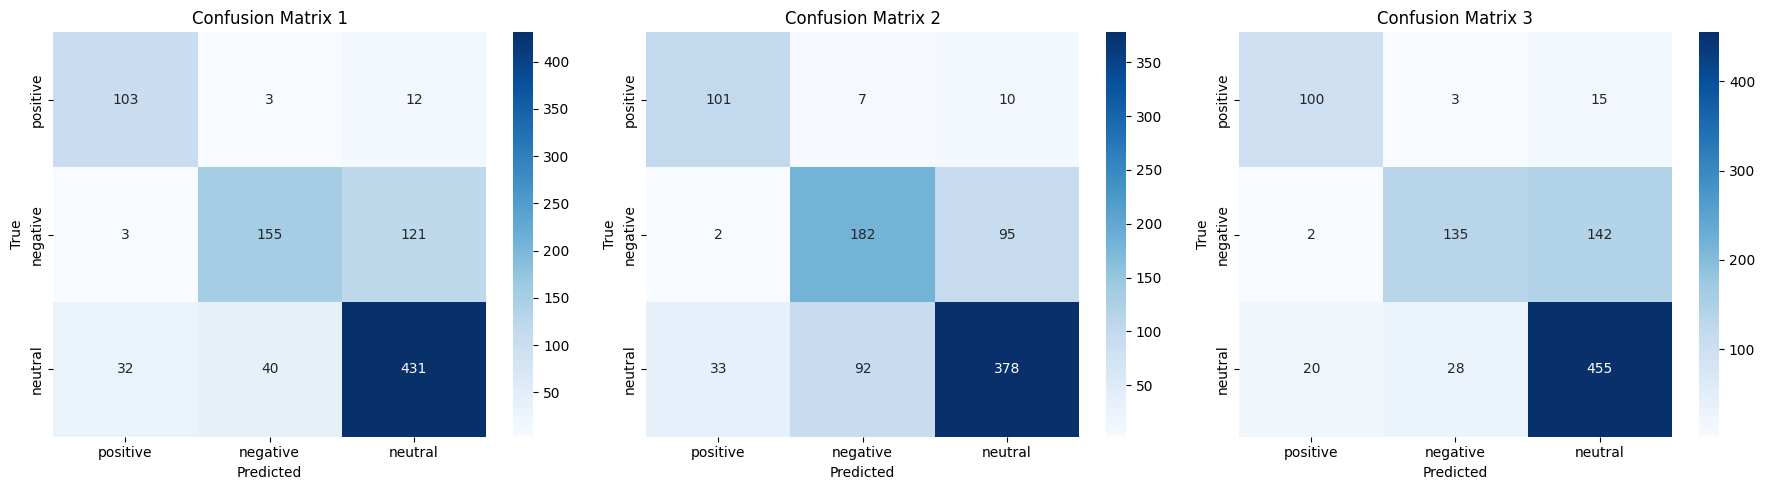

In [8]:

conf_matrix_cross_entropy = confusion_matrix(y_true = test_df['label'], y_pred = test_df['pred_cross_entropy'])
conf_matrix_weighted_cross_entropy = confusion_matrix(y_true = test_df['label'], y_pred = test_df['pred_weighted_cross_entropy'])
conf_matrix_focal_loss = confusion_matrix(y_true = test_df['label'], y_pred = test_df['pred_focal_loss'])

plot_conf_matrices([conf_matrix_cross_entropy,conf_matrix_weighted_cross_entropy,conf_matrix_focal_loss])

Die Verwechslungsmatrizen spiegeln hier auch das wieder, dass die Entscheidung, ob ein Sample negativ oder neutral ist ziemlich schwierig ist. Das haben wir selbst beim Labeln herausgefunden. Teilweise unsaubere Labels können daher nicht vollständig ausgeschlossen werden, was den Trainingsprozess erheblich beeinträchtigen kann.

Vielleicht gilt hier auch der Satz, den Herr Albrecht in der Vorlesung (so oder so ähnlich) gesagt hat:
> Wenn der Mensch das schon nicht auseinanderhalten kann, wie soll es das Modell dann auseinanderhalten können?

# Anwenden auf gesamten Datensatz und Analyse

In [10]:
df_interruptions = pd.read_csv('../_data/interruptions.csv')

In [12]:
df_interruptions = df_interruptions[~df_interruptions['comment_text'].apply(lambda value: not isinstance(value, str))]

In [13]:
import numpy as np
import torch
torch.cuda.empty_cache()

In [14]:
def save_predictions_in_chunks(df, model, chunk_size=100000, output_probabilities=False, output_dir='./'):
    num_chunks = len(df) // chunk_size + (1 if len(df) % chunk_size != 0 else 0)
    for i in range(2,num_chunks):
        print(f"Processing chunk {i+1}/{num_chunks}...")
        start_idx = i * chunk_size
        end_idx = min((i + 1) * chunk_size, len(df))
        chunk = df.iloc[start_idx:end_idx]

        # Predict sentiments for the chunk
        predictions = model.predict_sentiment_batches(chunk['comment_text'].to_list(), output_probabilities=output_probabilities)

        # Save predictions to .npy file
        np.save(f"{output_dir}/predictions_chunk_{i+1}.npy", predictions)
        print(f"Chunk {i+1} processed and saved to {output_dir}/predictions_chunk_{i+1}.npy")
        torch.cuda.empty_cache()

# Assuming df_interruptions is your DataFrame and model_cross_entropy is your model instance
save_predictions_in_chunks(df_interruptions, model_cross_entropy, chunk_size=75000, output_probabilities=False, output_dir='./')

Processing chunk 4/7...
Progress: 0.07; Classified 5000 samples. 
Progress: 0.13; Classified 10000 samples. 
Progress: 0.20; Classified 15000 samples. 
Progress: 0.27; Classified 20000 samples. 


KeyboardInterrupt: 

In [14]:

torch.cuda.empty_cache()

In [13]:
df_interruptions['sentiment'] = model_cross_entropy.predict_sentiment_batches(df_interruptions['comment_text'].to_list())

Progress: 0.01; Classified 5000 samples. 
Progress: 0.02; Classified 10000 samples. 
Progress: 0.03; Classified 15000 samples. 
Progress: 0.04; Classified 20000 samples. 
Progress: 0.05; Classified 25000 samples. 
Progress: 0.06; Classified 30000 samples. 
Progress: 0.07; Classified 35000 samples. 
Progress: 0.08; Classified 40000 samples. 
Progress: 0.09; Classified 45000 samples. 
Progress: 0.10; Classified 50000 samples. 
Progress: 0.12; Classified 55000 samples. 
Progress: 0.13; Classified 60000 samples. 
Progress: 0.14; Classified 65000 samples. 
Progress: 0.15; Classified 70000 samples. 
Progress: 0.16; Classified 75000 samples. 
Progress: 0.17; Classified 80000 samples. 
Progress: 0.18; Classified 85000 samples. 
Progress: 0.19; Classified 90000 samples. 
Progress: 0.20; Classified 95000 samples. 
Progress: 0.21; Classified 100000 samples. 
Progress: 0.22; Classified 105000 samples. 
Progress: 0.23; Classified 110000 samples. 
Progress: 0.24; Classified 115000 samples. 
Progress

KeyboardInterrupt: 